# Indian economy study, 2000 to 2025

Pulling GDP growth, inflation, FDI inflows and forex reserves for India from the World Bank API, then charting them together to see how the economy moved over 25 years.

In [4]:
import pandas as pd
import requests
import matplotlib.pyplot as plt

In [5]:
indicators = {
    "NY.GDP.MKTP.KD.ZG": "GDP growth (%)",
    "FP.CPI.TOTL.ZG": "Inflation (%)",
    "BX.KLT.DINV.WD.GD.ZS": "FDI inflows (% of GDP)",
    "FI.RES.TOTL.CD": "Forex reserves (USD)",
}

frames = []
for code, name in indicators.items():
    url = f"https://api.worldbank.org/v2/country/IND/indicator/{code}?format=json&per_page=100&date=2000:2025"
    data = requests.get(url, timeout=30).json()[1]
    df = pd.DataFrame([{"year": int(r["date"]), name: r["value"]} for r in data])
    frames.append(df.set_index("year"))

india = pd.concat(frames, axis=1).sort_index()
india["Forex reserves (USD bn)"] = india.pop("Forex reserves (USD)") / 1e9
india.round(2).tail(10)

,GDP growth (%),Inflation (%),FDI inflows (% of GDP),Forex reserves (USD bn)
year,,,,
2016,8.26,4.95,1.94,361.69
2017,6.80,3.33,1.51,412.61
2018,6.45,3.94,1.56,399.17
2019,3.87,3.73,1.78,463.47
2020,-5.78,6.62,2.41,590.23
2021,9.69,5.13,1.41,638.48
2022,7.61,6.70,1.54,567.30
2023,7.21,5.65,0.80,627.79
2024,7.10,4.95,0.72,643.04


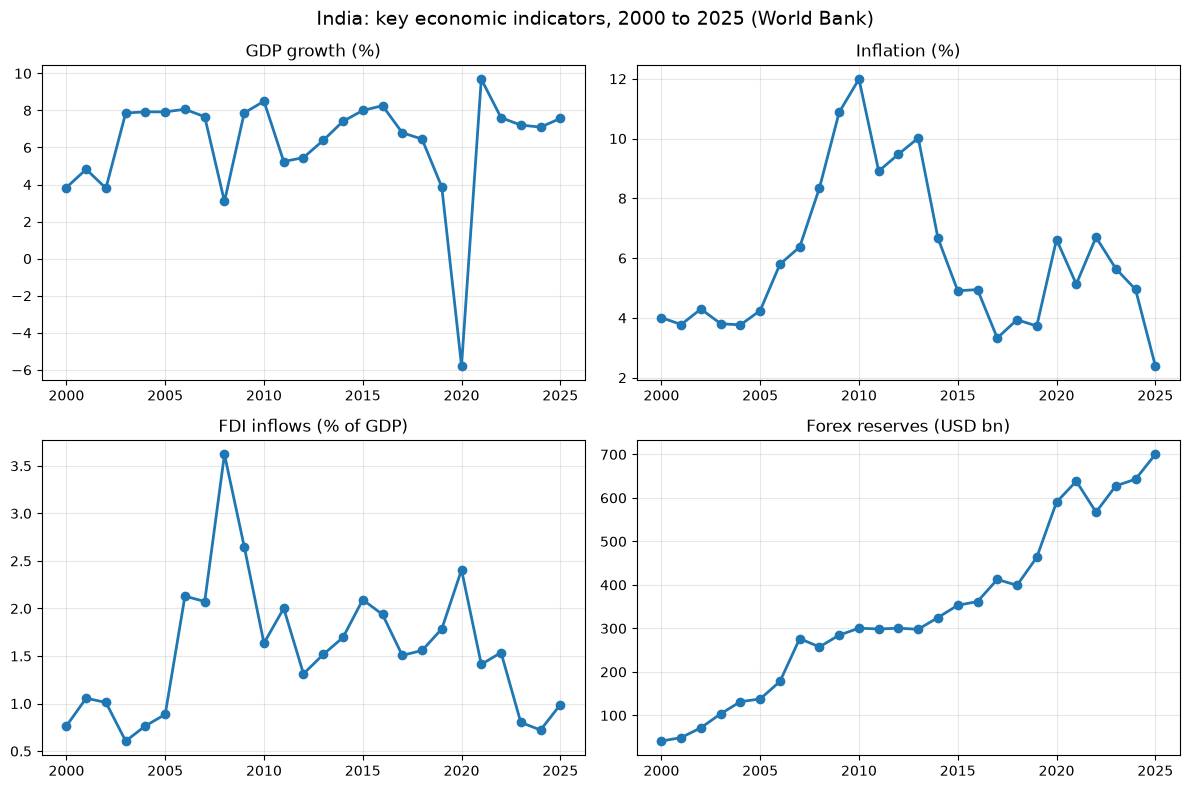

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, india.columns):
    india[col].plot(ax=ax, marker="o", linewidth=2)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.grid(alpha=0.3)

fig.suptitle("India: key economic indicators, 2000 to 2025 (World Bank)", fontsize=14)
plt.tight_layout()
plt.show()

## What the charts show

GDP growth took two big hits, 2008 (about 3.1%) and 2020 (-5.8% during COVID). Both times it bounced back within a year, and from 2022 it has stayed around 7 to 7.6%.

Inflation peaked near 12% in 2010 and has mostly come down since. 2025 is the lowest in the series at 2.4%.

FDI as a share of GDP fell from 2.4% in 2020 to 0.7 to 1.0% in 2023 to 2025. But this is a ratio, so some of the drop could just be GDP growing faster. Need to check FDI in dollar terms before calling it a real fall.

Forex reserves grew from about $40 bn in 2000 to about $700 bn in 2025, which is a much bigger buffer against currency shocks.

## Questions to look at next

- Reserves keep rising while FDI share is falling, so where is the money coming from? Could be portfolio inflows, remittances or valuation changes, would need more data to check.
- How much of the 2025 inflation drop is food prices vs core inflation?

Source: World Bank, World Development Indicators (NY.GDP.MKTP.KD.ZG, FP.CPI.TOTL.ZG, BX.KLT.DINV.WD.GD.ZS, FI.RES.TOTL.CD), pulled via API in October 2026. Latest year can get revised.